In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import sys
from pathlib import Path

# Ruta raíz del proyecto en Drive
PROJECT_PATH = Path("/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models")

# Carpetas principales
NOTEBOOKS_DIR = PROJECT_PATH / "notebooks"
SRC_DIR = PROJECT_PATH / "src"
CHECKPOINTS_DIR = PROJECT_PATH / "checkpoints"
RESULTS_DIR = PROJECT_PATH / "results"

# Añadir src al path para poder importar los .py
sys.path.insert(0, str(SRC_DIR))

# Crear carpetas si no existen
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_PATH =", PROJECT_PATH)
print("SRC_DIR =", SRC_DIR)
print("CHECKPOINTS_DIR =", CHECKPOINTS_DIR)
print("RESULTS_DIR =", RESULTS_DIR)

PROJECT_PATH = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models
SRC_DIR = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/src
CHECKPOINTS_DIR = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints
RESULTS_DIR = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/results


In [ ]:

import torch
import pandas as pd


from diffusion_utilities import plot_image_grid, plot_image_evolution

from evaluation_utils import (
    ModelConfig,
    get_mnist_digit_loader,
    compare_model_configs_bpd,
    generate_final_samples,
    train_or_load_mnist_classifier,
    get_real_mnist_digit_images,
    evaluate_fid_is_mnist,
    compute_bpd_for_model
)

In [ ]:
digit = 3
batch_size = 32

eval_loader = get_mnist_digit_loader(
    digit=digit,
    train=True,
    batch_size=batch_size,
    max_samples=128,
)

print("Evaluation loader ready.")

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 497kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.10MB/s]

Evaluation loader ready.


In [ ]:
checkpoint_paths = {
    "bm_mnist_digit3": CHECKPOINTS_DIR / "bm_mnist_digit3_best.pth",
    "ou_linear_digit3": CHECKPOINTS_DIR / "ou_mnist_digit3_linear.pth",
    "ou_cosine_digit3": CHECKPOINTS_DIR / "ou_mnist_digit3_cosine.pth",
    "ou_constant_digit3": CHECKPOINTS_DIR / "ou_mnist_digit3_constant.pth",
    "ou_all_digits_cosine": CHECKPOINTS_DIR / "ou_mnist_all_digits_cosine.pth",
}

configs = [
    ModelConfig(
        model_type="bm",
        schedule_name=None,
        checkpoint_path=str(checkpoint_paths["bm_mnist_digit3"]),
        sigma=25.0,
    ),
    ModelConfig(
        model_type="ou",
        schedule_name="linear",
        checkpoint_path=str(checkpoint_paths["ou_linear_digit3"]),
        sigma=25.0,
    ),
    ModelConfig(
        model_type="ou",
        schedule_name="cosine",
        checkpoint_path=str(checkpoint_paths["ou_cosine_digit3"]),
        sigma=25.0,
    ),
    ModelConfig(
        model_type="ou",
        schedule_name="constant",
        checkpoint_path=str(checkpoint_paths["ou_constant_digit3"]),
        sigma=25.0,
    ),
]

configs

[ModelConfig(model_type='bm', schedule_name=None, checkpoint_path='/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/bm_mnist_digit3_best.pth', sigma=25.0),
 ModelConfig(model_type='ou', schedule_name='linear', checkpoint_path='/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/ou_mnist_digit3_linear.pth', sigma=25.0),
 ModelConfig(model_type='ou', schedule_name='cosine', checkpoint_path='/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/ou_mnist_digit3_cosine.pth', sigma=25.0),
 ModelConfig(model_type='ou', schedule_name='constant', checkpoint_path='/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/ou_mnist_digit3_constant.pth', sigma=25.0)]

## Comparison of quality metrics on a base model

We first evaluate three metrics on a base model: the Brownian-motion / variance-exploding model using the Euler-Maruyama sampler.

The metrics are:
- BPD: likelihood-based metric.
- FID-MNIST: distance between real and generated images in the feature space of a MNIST classifier.
- IS-MNIST: classifier-based confidence/diversity score.

In [ ]:
# Reproducibility
_ = torch.manual_seed(123)

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [ ]:
classifier_checkpoint_path = CHECKPOINTS_DIR / "mnist_classifier.pth"
print("Classifier checkpoint:", classifier_checkpoint_path)

mnist_classifier = train_or_load_mnist_classifier(
    checkpoint_path=classifier_checkpoint_path,
    device=device,
    n_epochs=3,
    batch_size=128,
)

Classifier checkpoint: /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/mnist_classifier.pth
Loaded MNIST classifier: /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/mnist_classifier.pth


In [ ]:
base_config = configs[0]  # BM / VE

n_eval_images = 128

generated_bm_euler, traj_bm_euler = generate_final_samples(
    config=base_config,
    sampler_name="euler",
    n_images=n_eval_images,
    device=device,
    n_steps=500,
)

real_digit_images = get_real_mnist_digit_images(
    digit=3,
    n_images=n_eval_images,
    device=device,
)

print("Generated images:", generated_bm_euler.shape)
print("Real images:", real_digit_images.shape)

Generated images: torch.Size([128, 1, 28, 28])
Real images: torch.Size([128, 1, 28, 28])


In [ ]:
bm_fid_is = evaluate_fid_is_mnist(
    classifier=mnist_classifier,
    real_images=real_digit_images,
    generated_images=generated_bm_euler,
)

bm_fid_is

/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/src/evaluation_utils.py:727: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  cov_sqrt = sqrtm(cov_real @ cov_gen)


{'fid_mnist': 77.05656579284317, 'is_mnist': 1.1994389295578003}

In [ ]:
df_metric_comparison_base = pd.DataFrame([
    {
        "base_model": "BM / VE",
        "sampler": "Euler-Maruyama",
        "FID-MNIST": bm_fid_is["fid_mnist"],
        "IS-MNIST": bm_fid_is["is_mnist"],
    }
])

df_metric_comparison_base

,base_model,sampler,FID-MNIST,IS-MNIST
0,BM / VE,Euler-Maruyama,77.056566,1.199439


In [ ]:
model_rows = []

n_eval_images = 128
real_digit_images = get_real_mnist_digit_images(
    digit=3,
    n_images=n_eval_images,
    device=device,
)

for cfg in configs:
    generated_images, _ = generate_final_samples(
        config=cfg,
        sampler_name="euler",
        n_images=n_eval_images,
        device=device,
        n_steps=500,
    )

    metrics = evaluate_fid_is_mnist(
        classifier=mnist_classifier,
        real_images=real_digit_images,
        generated_images=generated_images,
    )

    model_rows.append({
        "model_type": cfg.model_type,
        "schedule_name": cfg.schedule_name,
        "sampler": "Euler-Maruyama",
        "FID-MNIST": metrics["fid_mnist"],
        "IS-MNIST": metrics["is_mnist"],
    })

df_model_comparison_fid = pd.DataFrame(model_rows)
df_model_comparison_fid = (
    df_model_comparison_fid
    .sort_values("FID-MNIST")
    .reset_index(drop=True)
)
df_model_comparison_fid

# BPD is expensive, so we evaluate it on a small subset
bpd_loader = get_mnist_digit_loader(
    digit=3,
    train=True,
    batch_size=2,
    max_samples=8,
)

df_bpd_comparison = compare_model_configs_bpd(
    configs=configs,
    data_loader=bpd_loader,
    device=device,
    n_steps_likelihood=25,
    eps=1.0e-3,
)

df_bpd_summary = df_bpd_comparison[
    ["model_type", "schedule_name", "mean_bpd"]
].rename(columns={"mean_bpd": "BPD"})

df_model_comparison = df_model_comparison_fid.merge(
    df_bpd_summary,
    on=["model_type", "schedule_name"],
    how="left",
)

df_model_comparison = df_model_comparison.sort_values(
    "FID-MNIST"
).reset_index(drop=True)

df_model_comparison

/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/src/evaluation_utils.py:727: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  cov_sqrt = sqrtm(cov_real @ cov_gen)


,model_type,schedule_name,sampler,FID-MNIST,IS-MNIST,BPD
0,ou,cosine,Euler-Maruyama,46.981548,1.129427,-5.341077
1,bm,None,Euler-Maruyama,54.261062,1.303574,-10.503363
2,ou,linear,Euler-Maruyama,121.866725,1.520595,-0.691975
3,ou,constant,Euler-Maruyama,159.715168,1.243330,-7.514598


In [ ]:
best_model_row = df_model_comparison_fid.iloc[0]
best_model_row

,0
model_type,ou
schedule_name,cosine
sampler,Euler-Maruyama
FID-MNIST,46.981548
IS-MNIST,1.129427


In [ ]:
best_config_fid = None

for cfg in configs:
    same_model = cfg.model_type == best_model_row["model_type"]

    if pd.isna(best_model_row["schedule_name"]):
        same_schedule = cfg.schedule_name is None
    else:
        same_schedule = cfg.schedule_name == best_model_row["schedule_name"]

    if same_model and same_schedule:
        best_config_fid = cfg
        break

print(best_config_fid)

ModelConfig(model_type='ou', schedule_name='cosine', checkpoint_path='/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/ou_mnist_digit3_cosine.pth', sigma=25.0)


In [ ]:
config=best_config_fid

In [ ]:
sampler_rows = []

sampler_models = [
    ("BM / VE", configs[0]),
    ("OU / VP cosine", best_config_fid),
]

for model_name, cfg in sampler_models:
    for sampler_name in ["euler", "predictor_corrector", "ode"]:
        generated_images, _ = generate_final_samples(
            config=cfg,
            sampler_name=sampler_name,
            n_images=n_eval_images,
            device=device,
            n_steps=500,
            n_corrector_steps=1,
            snr=0.16,
        )

        metrics = evaluate_fid_is_mnist(
            classifier=mnist_classifier,
            real_images=real_digit_images,
            generated_images=generated_images,
        )

        sampler_rows.append({
            "model": model_name,
            "sampler": sampler_name,
            "FID-MNIST": metrics["fid_mnist"],
            "IS-MNIST": metrics["is_mnist"],
        })

df_sampler_comparison_all = pd.DataFrame(sampler_rows)
df_sampler_comparison_all = (
    df_sampler_comparison_all
    .sort_values("FID-MNIST")
    .reset_index(drop=True)
)

bpd_map = {}

for cfg in configs:
    key = "BM / VE" if cfg.model_type == "bm" else f"OU / VP {cfg.schedule_name}"
    bpd_value = df_bpd_summary[
        (df_bpd_summary["model_type"] == cfg.model_type)
        & (
            (df_bpd_summary["schedule_name"] == cfg.schedule_name)
            | (df_bpd_summary["schedule_name"].isna() & (cfg.schedule_name is None))
        )
    ]["BPD"].iloc[0]
    bpd_map[key] = bpd_value

df_sampler_comparison_all["BPD"] = df_sampler_comparison_all["model"].map(bpd_map)

df_sampler_comparison_all

/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/src/evaluation_utils.py:727: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  cov_sqrt = sqrtm(cov_real @ cov_gen)


,model,sampler,FID-MNIST,IS-MNIST,BPD
0,OU / VP cosine,predictor_corrector,48.671786,1.201501,-5.341077
1,OU / VP cosine,euler,58.520205,1.047801,-5.341077
2,BM / VE,predictor_corrector,71.618907,1.061275,-10.503363
3,BM / VE,euler,92.668786,1.329152,-10.503363
4,BM / VE,ode,98.623575,1.381597,-10.503363
5,OU / VP cosine,ode,389.892118,1.860360,-5.341077


In [ ]:
sampler_rows = []

for sampler_name in ["euler", "predictor_corrector", "ode"]:
    generated_images, traj = generate_final_samples(
        config=best_config_fid,
        sampler_name=sampler_name,
        n_images=n_eval_images,
        device=device,
        n_steps=500,
        n_corrector_steps=1,
        snr=0.16,
    )

    metrics = evaluate_fid_is_mnist(
        classifier=mnist_classifier,
        real_images=real_digit_images,
        generated_images=generated_images,
    )

    sampler_rows.append({
        "model_type": best_config_fid.model_type,
        "schedule_name": best_config_fid.schedule_name,
        "sampler": sampler_name,
        "FID-MNIST": metrics["fid_mnist"],
        "IS-MNIST": metrics["is_mnist"],
    })

df_sampler_comparison = pd.DataFrame(sampler_rows)
df_sampler_comparison = (
    df_sampler_comparison
    .sort_values("FID-MNIST")
    .reset_index(drop=True)
)


bpd_best_model = df_bpd_summary[
    (df_bpd_summary["model_type"] == best_config_fid.model_type)
    & (df_bpd_summary["schedule_name"] == best_config_fid.schedule_name)
]["BPD"].iloc[0]

df_sampler_comparison["BPD"] = bpd_best_model

df_sampler_comparison

/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/src/evaluation_utils.py:727: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  cov_sqrt = sqrtm(cov_real @ cov_gen)


,model_type,schedule_name,sampler,FID-MNIST,IS-MNIST,BPD
0,ou,cosine,euler,49.082103,1.224498,-5.341077
1,ou,cosine,predictor_corrector,57.012980,1.190150,-5.341077
2,ou,cosine,ode,379.295091,1.740831,-5.341077


## Final conclusion

In this exercise, we evaluated the quality of generated images using different metrics.

First, we compared BPD, FID-MNIST and IS-MNIST on a base model (BM / VE with Euler-Maruyama). While BPD is theoretically important, it is computationally expensive in practice due to probability-flow ODE likelihood estimation. Therefore, we selected FID-MNIST as the main metric for practical comparisons.

Using FID-MNIST (where lower values indicate better quality), we compared different diffusion models. The best result was obtained by the OU / VP model with cosine noise schedule.

Next, we compared sampling strategies (Euler-Maruyama, predictor-corrector and probability flow ODE).

Finally, combining all experiments, the best overall configuration was:

**OU / VP + cosine schedule + Euler-Maruyama sampler**

This configuration provides the best trade-off between image quality and computational cost.

## Evolution of FID-MNIST across training epochs

To analyze how training time affects sample quality, we evaluate several intermediate checkpoints of the OU / VP cosine model. For each checkpoint, we generate samples using Euler-Maruyama and compute FID-MNIST against real MNIST digit-3 images.

Lower FID-MNIST values indicate better generated image quality.

In [ ]:
epochs_to_evaluate = [10, 20, 50, 100, 200]

epoch_configs = [
    ModelConfig(
        model_type="ou",
        schedule_name="cosine",
        checkpoint_path=str(CHECKPOINTS_DIR / f"ou_mnist_digit3_cosine_epoch_{epoch}.pth"),
        sigma=25.0,
    )
    for epoch in epochs_to_evaluate
]

for epoch, cfg in zip(epochs_to_evaluate, epoch_configs):
    print(epoch, cfg.checkpoint_path, os.path.exists(cfg.checkpoint_path))

10 /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/ou_mnist_digit3_cosine_epoch_10.pth True
20 /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/ou_mnist_digit3_cosine_epoch_20.pth True
50 /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/ou_mnist_digit3_cosine_epoch_50.pth True
100 /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/ou_mnist_digit3_cosine_epoch_100.pth True
200 /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/ou_mnist_digit3_cosine_epoch_200.pth True


In [ ]:
epoch_rows = []

n_eval_images = 128

real_digit_images = get_real_mnist_digit_images(
    digit=3,
    n_images=n_eval_images,
    device=device,
)

# BPD subset: small because it is expensive
bpd_loader = get_mnist_digit_loader(
    digit=3,
    train=True,
    batch_size=2,
    max_samples=8,
)

for epoch, cfg in zip(epochs_to_evaluate, epoch_configs):
    generated_images, _ = generate_final_samples(
        config=cfg,
        sampler_name="euler",
        n_images=n_eval_images,
        device=device,
        n_steps=500,
    )

    metrics = evaluate_fid_is_mnist(
        classifier=mnist_classifier,
        real_images=real_digit_images,
        generated_images=generated_images,
    )

    bpd_stats = compute_bpd_for_model(
        config=cfg,
        data_loader=bpd_loader,
        device=device,
        n_steps_likelihood=25,
        eps=1.0e-3,
    )

    epoch_rows.append({
        "epoch": epoch,
        "FID-MNIST": metrics["fid_mnist"],
        "IS-MNIST": metrics["is_mnist"],
        "BPD": bpd_stats["mean_bpd"],
    })

df_epoch_fid = pd.DataFrame(epoch_rows)
df_epoch_fid

/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/src/evaluation_utils.py:727: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  cov_sqrt = sqrtm(cov_real @ cov_gen)


,epoch,FID-MNIST,IS-MNIST,BPD
0,10,1404.114677,1.987087,6.400520
1,20,231.980641,1.719775,2.884631
2,50,65.960541,1.219518,0.066004
3,100,90.829922,1.455119,-4.148103
4,200,52.504113,1.087056,-7.000072


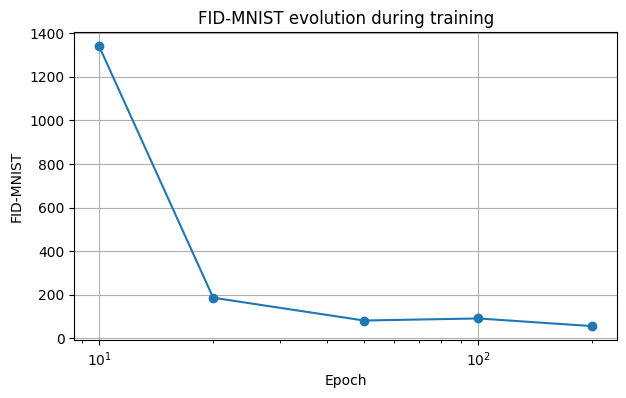

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.plot(
    df_epoch_fid["epoch"],
    df_epoch_fid["FID-MNIST"],
    marker="o",
)

plt.xscale("log")
plt.xlabel("Epoch")
plt.ylabel("FID-MNIST")
plt.title("FID-MNIST evolution during training")
plt.grid(True)
plt.show()